Хрипков Т. А.

ИУ5-65Б

Вариант 21: задача 3, набор данных 5

# Загрузка данных из Kaggle

In [4]:
import kagglehub
import os

# Скачивание датасета
dataset_path = kagglehub.dataset_download("mohansacharya/graduate-admissions")
csv_files = [f for f in os.listdir(dataset_path) if f.endswith('.csv')]
csv_path = os.path.join(dataset_path, csv_files[0])

Using Colab cache for faster access to the 'graduate-admissions' dataset.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split

df = pd.read_csv(csv_path)

print(f"Данные загружены: {df.shape[0]} строк, {df.shape[1]} колонок")
print("\nТипы данных:")
print(df.dtypes)

Данные загружены: 400 строк, 9 колонок

Типы данных:
Serial No.             int64
GRE Score              int64
TOEFL Score            int64
University Rating      int64
SOP                  float64
LOR                  float64
CGPA                 float64
Research               int64
Chance of Admit      float64
dtype: object


# Предобработка данных: масштабирование и кодирование

В задачах машинного обучения качество моделей сильно зависит от подготовки данных. Два важных этапа предобработки:

1. **Масштабирование числовых признаков** — приведение признаков к единому масштабу
2. **Кодирование категориальных признаков** — преобразование текстовых меток в числовой формат

Рассмотрим математическую основу и реализацию на примере учебного набора данных.

# Масштабирование числовых признаков

Многие алгоритмы машинного обучения чувствительны к масштабу признаков: если признаки имеют разный масштаб, признак с большими значениями будет доминировать в функции потерь.

## Z-оценка

Преобразует данные так, чтобы они имели нулевое среднее и единичную дисперсию:

$$
z = \frac{x - \mu}{\sigma}, \quad \text{где} \quad
\mu = \frac{1}{n}\sum_{i=1}^{n}x_i, \quad
\sigma = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(x_i - \mu)^2}
$$

**Преимущества:**
- Сохраняет форму распределения исходных данных
- Устойчивее к выбросам, чем MinMax
- Идеально для признаков с нормальным или близким к нормальному распределением

**Ограничения:**
- Не гарантирует фиксированный диапазон значений
- Чувствителен к сильным выбросам (влияют на $\mu$ и $\sigma$)

## MinMax

Линейно преобразует данные в заданный интервал, обычно $[0, 1]$:

$$
x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}} \cdot (max_{range} - min_{range}) + min_{range}
$$

Для диапазона $[0, 1]$ формула упрощается:

$$
x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}}
$$

**Преимущества:**
- Все значения находятся в известном диапазоне
- Сохраняет относительные расстояния между точками
- Требуется для нейронных сетей с сигмоидными/тангенс-активациями

**Ограничения:**
- Чрезвычайно чувствителен к выбросам ($x_{\max}$ и $x_{\min}$ могут быть аномальными)
- При появлении новых данных за пределами исходного диапазона возможны значения $< 0$ или $> 1$

In [17]:
# Проведем масштабирование признака GRE Score

gre_data = df[['GRE Score']].dropna()

print(f"Исходный GRE Score: min={gre_data['GRE Score'].min():.2f}, max={gre_data['GRE Score'].max():.2f}")
print(f"Среднее: {gre_data['GRE Score'].mean():.2f}, Std: {gre_data['GRE Score'].std():.2f}")

# Z-оценка
scaler_standard = StandardScaler()
gre_standard = scaler_standard.fit_transform(gre_data)

# MinMax масштабирование
scaler_minmax = MinMaxScaler(feature_range=(0, 1))
gre_minmax = scaler_minmax.fit_transform(gre_data)

df_scaled = df.copy()
df_scaled['GRE_Standard'] = gre_standard
df_scaled['GRE_MinMax'] = gre_minmax

print(f"\nПосле Z-оценки: min={gre_standard.min():.3f}, max={gre_standard.max():.3f}")
print(f"После MinMax масштабирования: min={gre_minmax.min():.3f}, max={gre_minmax.max():.3f}")

Исходный GRE Score: min=290.00, max=340.00
Среднее: 316.81, Std: 11.47

После Z-оценки: min=-2.339, max=2.024
После MinMax масштабирования: min=0.000, max=1.000


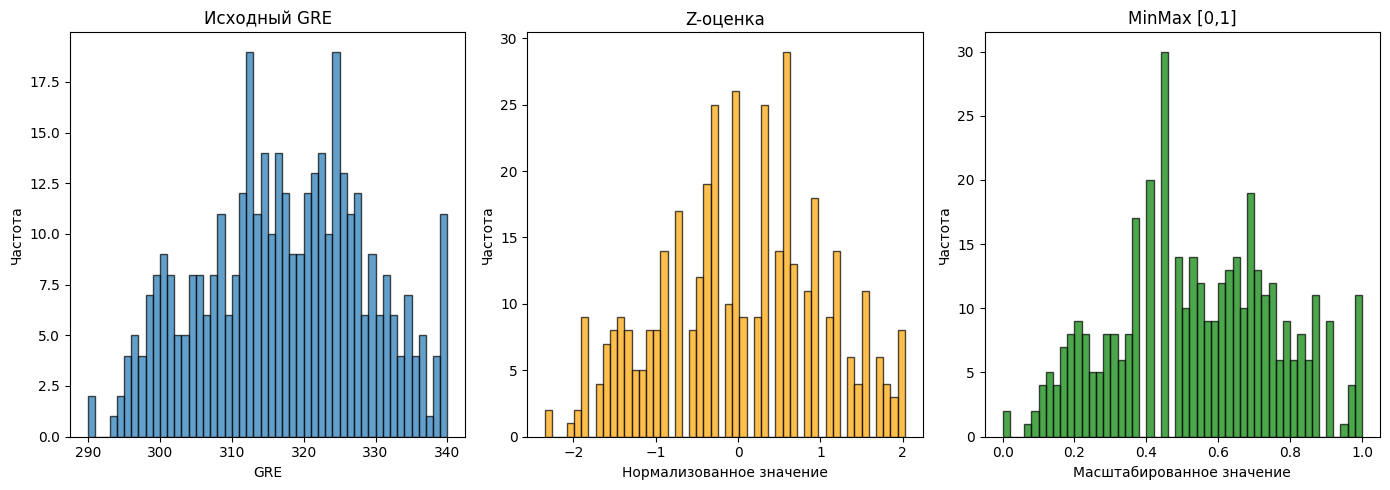

In [18]:
# Визуализация
plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.hist(df['GRE Score'].dropna(), bins=50, edgecolor='black', alpha=0.7)
plt.title('Исходный GRE')
plt.xlabel('GRE')
plt.ylabel('Частота')

plt.subplot(1, 3, 2)
plt.hist(gre_standard, bins=50, edgecolor='black', alpha=0.7, color='orange')
plt.title('Z-оценка')
plt.xlabel('Нормализованное значение')
plt.ylabel('Частота')

plt.subplot(1, 3, 3)
plt.hist(gre_minmax, bins=50, edgecolor='black', alpha=0.7, color='green')
plt.title('MinMax [0,1]')
plt.xlabel('Масштабированное значение')
plt.ylabel('Частота')

plt.tight_layout()
plt.show()

# Кодирование категориальных признаков

Категориальные признаки делятся на два типа:

- **Номинальные** (без порядка)
- **Ординальные** (с порядком)

## Label Encoding

Присваивает каждой уникальной категории целое число:

$$
f_{label}: C \rightarrow \{0, 1, 2, ..., k-1\}, \quad \text{где } |C| = k
$$

**Преимущества:**
- Компактное представление (одна колонка вместо $k$)
- Эффективно для деревьев решений (не интерпретируют числа как порядок)

**Недостатки:**
- Создаёт **ложный порядок**: модель может интерпретировать $2 > 1 > 0$ как числовое отношение
- Не подходит для линейных моделей и нейросетей при работе с номинальными признаками

### One-Hot Encoding

Создаёт $k$ бинарных признаков для $k$ уникальных категорий:

$$
f_{ohe}: C \rightarrow \{0, 1\}^k, \quad \text{где } \sum_{j=1}^{k} x_j = 1
$$

**Преимущества:**
- Не создаёт ложных порядковых зависимостей
- Интерпретируемо: каждый признак соответствует конкретной категории
- Универсально для всех типов моделей

**Недостатки:**
- При большом $k$ резко растёт число признаков
- Много нулей
- Мультиколлинеарность (сумма колонок = 1)

In [19]:
# Выберем ординальный признак University Rating для кодирования
print(f"Возможные рейтинги: {df['University Rating'].nunique()}")
print(f"Значения: {df['University Rating'].unique()}")
print(f"\nРаспределение:\n{df['University Rating'].value_counts()}")

Возможные рейтинги: 5
Значения: [4 3 2 5 1]

Распределение:
University Rating
3    133
2    107
4     74
5     60
1     26
Name: count, dtype: int64


In [20]:

# Label Encoding
le = LabelEncoder()
df_label = df.copy()
df_label['Rating_Label'] = le.fit_transform(df_label['University Rating'])

print(f"\nLabel Encoding:")
mapping_le = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"Словарь соответствия: {mapping_le}")

# One-Hot Encoding
df_ohe = df.copy()
rating_ohe = pd.get_dummies(df_ohe['University Rating'], prefix='University Rating', drop_first=False)
df_ohe = pd.concat([df_ohe, rating_ohe], axis=1)

print(f"\nOne-Hot Encoding:")
print(f"Создано колонок: {rating_ohe.shape[1]}")
print(f"Имена колонок: {list(rating_ohe.columns)}")


Label Encoding:
Словарь соответствия: {np.int64(1): np.int64(0), np.int64(2): np.int64(1), np.int64(3): np.int64(2), np.int64(4): np.int64(3), np.int64(5): np.int64(4)}

One-Hot Encoding:
Создано колонок: 5
Имена колонок: ['University Rating_1', 'University Rating_2', 'University Rating_3', 'University Rating_4', 'University Rating_5']


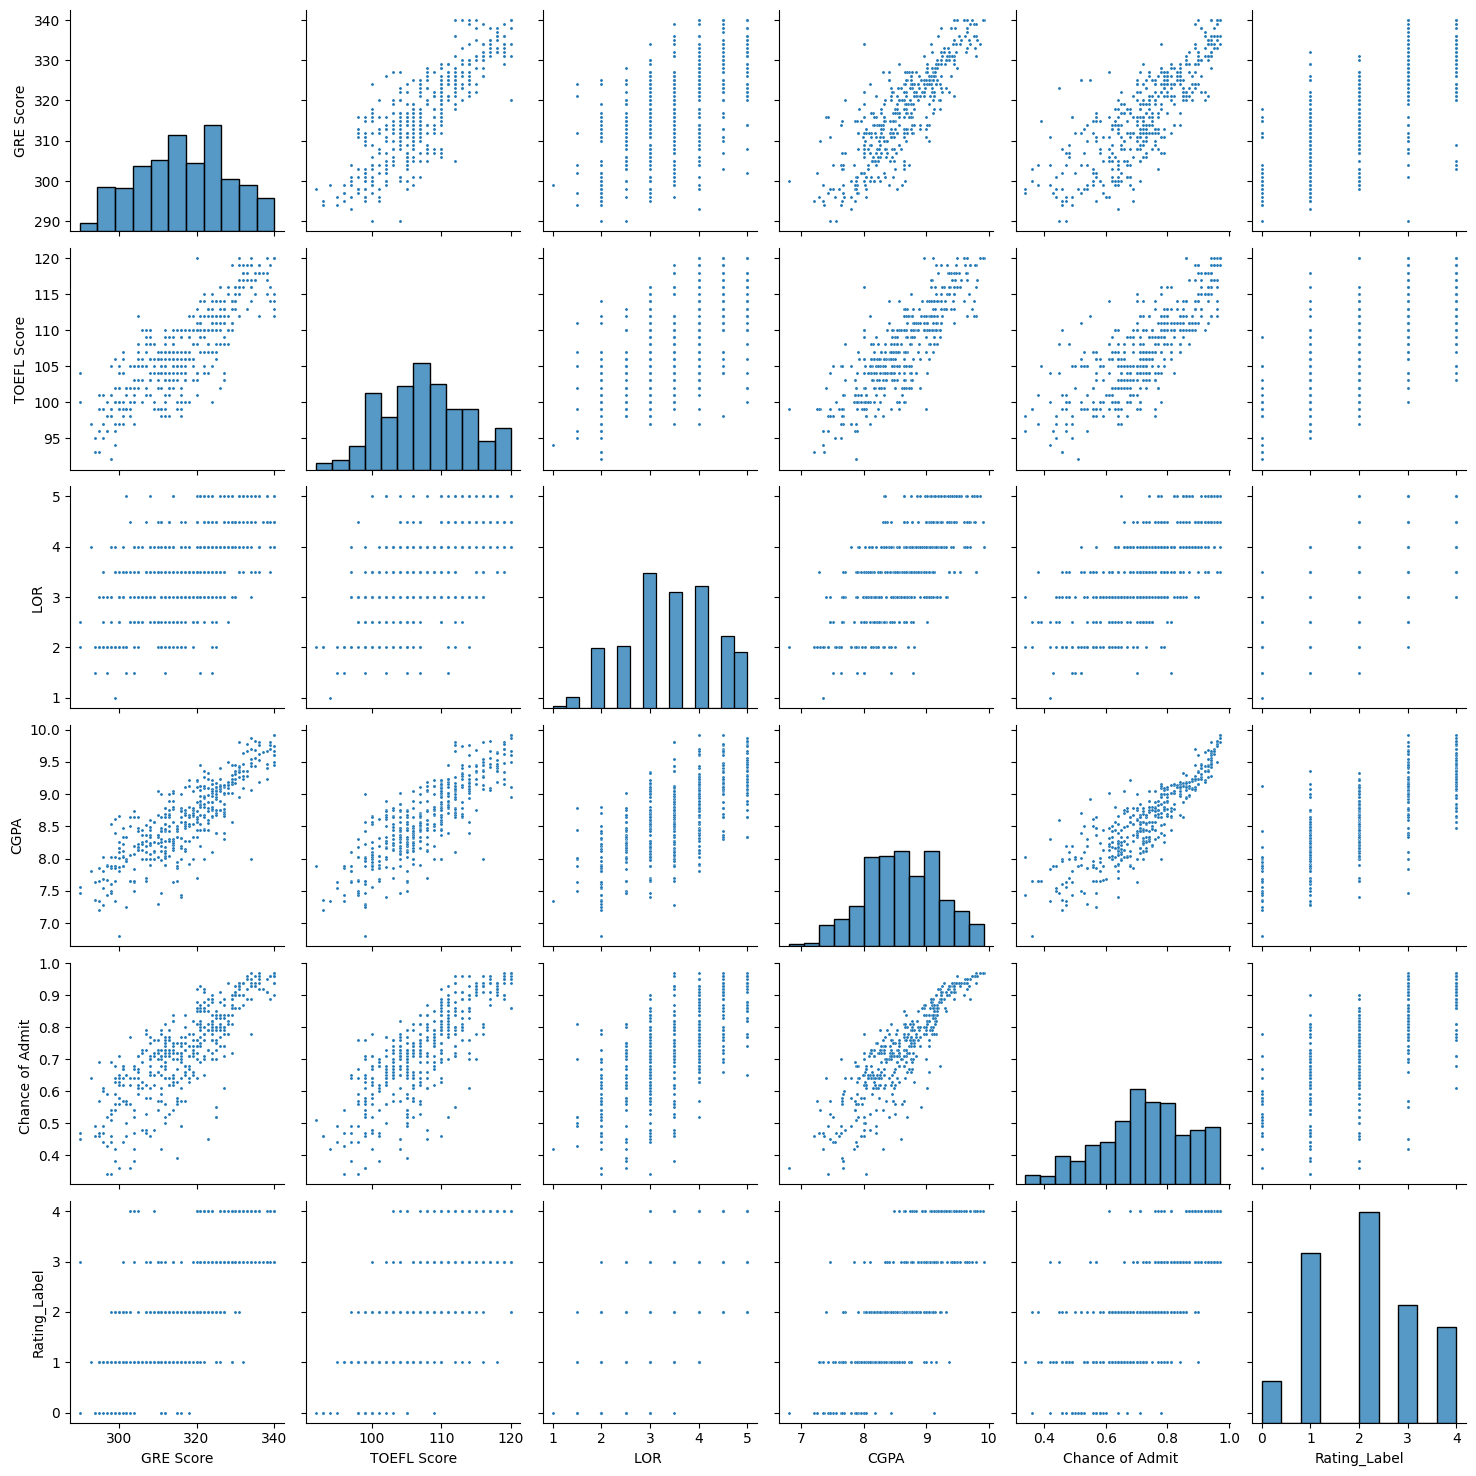

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# Исключаем столбец 'Serial No.' для построения парных диаграмм, а также малозначащие колонки, которые не дадут понятий о связях
df_no_number = df_label.drop(columns=['Serial No.', 'Research', 'University Rating', 'SOP'])

# Построение парных диаграмм
sns.pairplot(df_no_number, plot_kws={'s': 5})
plt.show()

Исходя из графиков, о связях между величинами можно сказать следующее:
  - GRE Score – Chance of Admit: Наблюдается явная положительная зависимость: чем выше балл GRE, тем выше вероятность поступления.
  - TOEFL Score – Chance of Admit: Аналогично, существует выраженная положительная связь: более высокие результаты TOEFL коррелируют с большими шансами на поступление.
  - CGPA – Chance of Admit: Наблюдается сильная положительная зависимость: чем выше средний балл (CGPA), тем выше вероятность быть принятым.
  - SOP – LOR: Зависимость слабая или отсутствует. Оценки мотивационного письма и рекомендательных писем варьируются независимо друг от друга.
  - Research – Chance of Admit: Видна слабая положительная тенденция: наличие исследовательского опыта немного увеличивает шансы, но разброс данных велик.
  - University Rating – SOP/LOR: Зависимость слабая. Рейтинг университета не сильно коррелирует с оценками дополнительных документов.
  - GRE Score – TOEFL Score: Наблюдается положительная корреляция: студенты с высокими баллами GRE, как правило, имеют и высокие баллы TOEFL.

# Выводы

## Для признака GRE Score (числовой, нормальное распределение):

Рекомендуемый метод: Z-оценка

**Обоснование:**
- Гистограмма распределения баллов GRE имеет форму, близкую к нормальному (колоколообразную)
- StandardScaler центрирует данные вокруг нуля и приводит дисперсию к единице, что идеально для такого распределения
- Важна для корректной работы алгоритмов, чувствительных к масштабу (например, линейные модели или методы расстояний)

## Для признака University Rating (категориальный, ординальный):

Рекомендуемый метод: Label Encoding

**Обоснование:**
- Рейтинг университета имеет естественный порядок: рейтинг 5 выше, чем 4, а 4 выше, чем 1
- Label Encoding (или использование исходных числовых значений) сохраняет эту иерархию, позволяя модели понимать разницу между уровнями
- One-Hot Encoding не подходит, так как он превратил бы ординальный признак в номинальный, уничтожив информацию о порядке ранжирования
- Визуально видно, что влияние рейтинга на поступление монотонно возрастает, что подтверждает важность сохранения порядка